# Exploración de datos - Multimodal CIC Maldroid 2020

**Autores:** Juan Diego Sánchez, Luis Fajardo, Jorge Bustamante, Estefanía Laverde

## Datos Tabulares

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import os

import warnings
warnings.filterwarnings('ignore')

In [47]:
# lectura de los datos tabulares - juntar train y test
train_df = pd.read_csv('datasets/Tabular/train-tabular.csv')
test_df = pd.read_csv('datasets/Tabular/test-tabular.csv')
data_df = pd.concat([train_df, test_df], ignore_index=True)

data_df.head()

,apk_name,permission.CALL_PHONE,permission.INTERNET,permission.READ_EXTERNAL_STORAGE,permission.READ_PHONE_STATE,permission.WRITE_EXTERNAL_STORAGE,permission.WRITE_SMS,permission.INSTALL_SHORTCUT,permission.C2D_MESSAGE,permission.ACCESS_NETWORK_STATE,...,permission.ACTION_HEADSET_PLUG,action.REPLENISH,action.VISA_SDK_NOTIFICATION,TaobaoRecvService,EMChatService,InnerService,ChargingDetectorService,DownloadReceiverService,AudioPlayService,Class
0,0008b849c70477faf464e80df6c7ea91569f78bd2f13af...,0,1,0,1,1,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,adware
1,0015ae7c27688d45f79170dcea16131ce557912a1a0c5f...,0,1,0,1,1,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,adware
2,00325582d7caaf0f36ad333869df444a1aa39326e60745...,0,1,0,1,1,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,adware
3,00567501fe3517b1bf6b363dd6c4d0972a77c591b0d7c2...,0,1,0,1,1,0,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,adware
4,00621e015191863041e78726b863b7e1374b17fda69036...,1,1,0,1,1,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,adware


In [48]:
print(data_df.shape, train_df.shape, test_df.shape)

(16691, 402) (11683, 402) (5008, 402)


El dataset contiene 16691 datos, cada uno con 402 características. De la separación inicial en train y test, train contiene 11683 datos y test contiene 5008.

### Distribución de las etiquetas

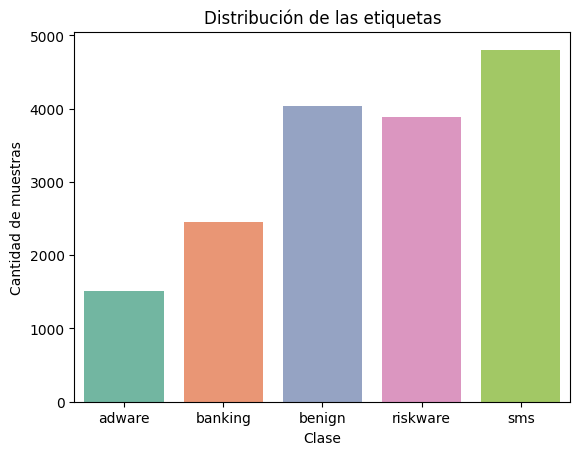

In [49]:
y = data_df['Class']
sns.countplot(x=y, palette='Set2', hue=y)
plt.title('Distribución de las etiquetas')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.savefig('images_exploration/distribucion_etiquetas.pdf')
plt.show()

### Matriz de correlación
Al ser muchas características, se muestran solo las top k características más correlacionadas.

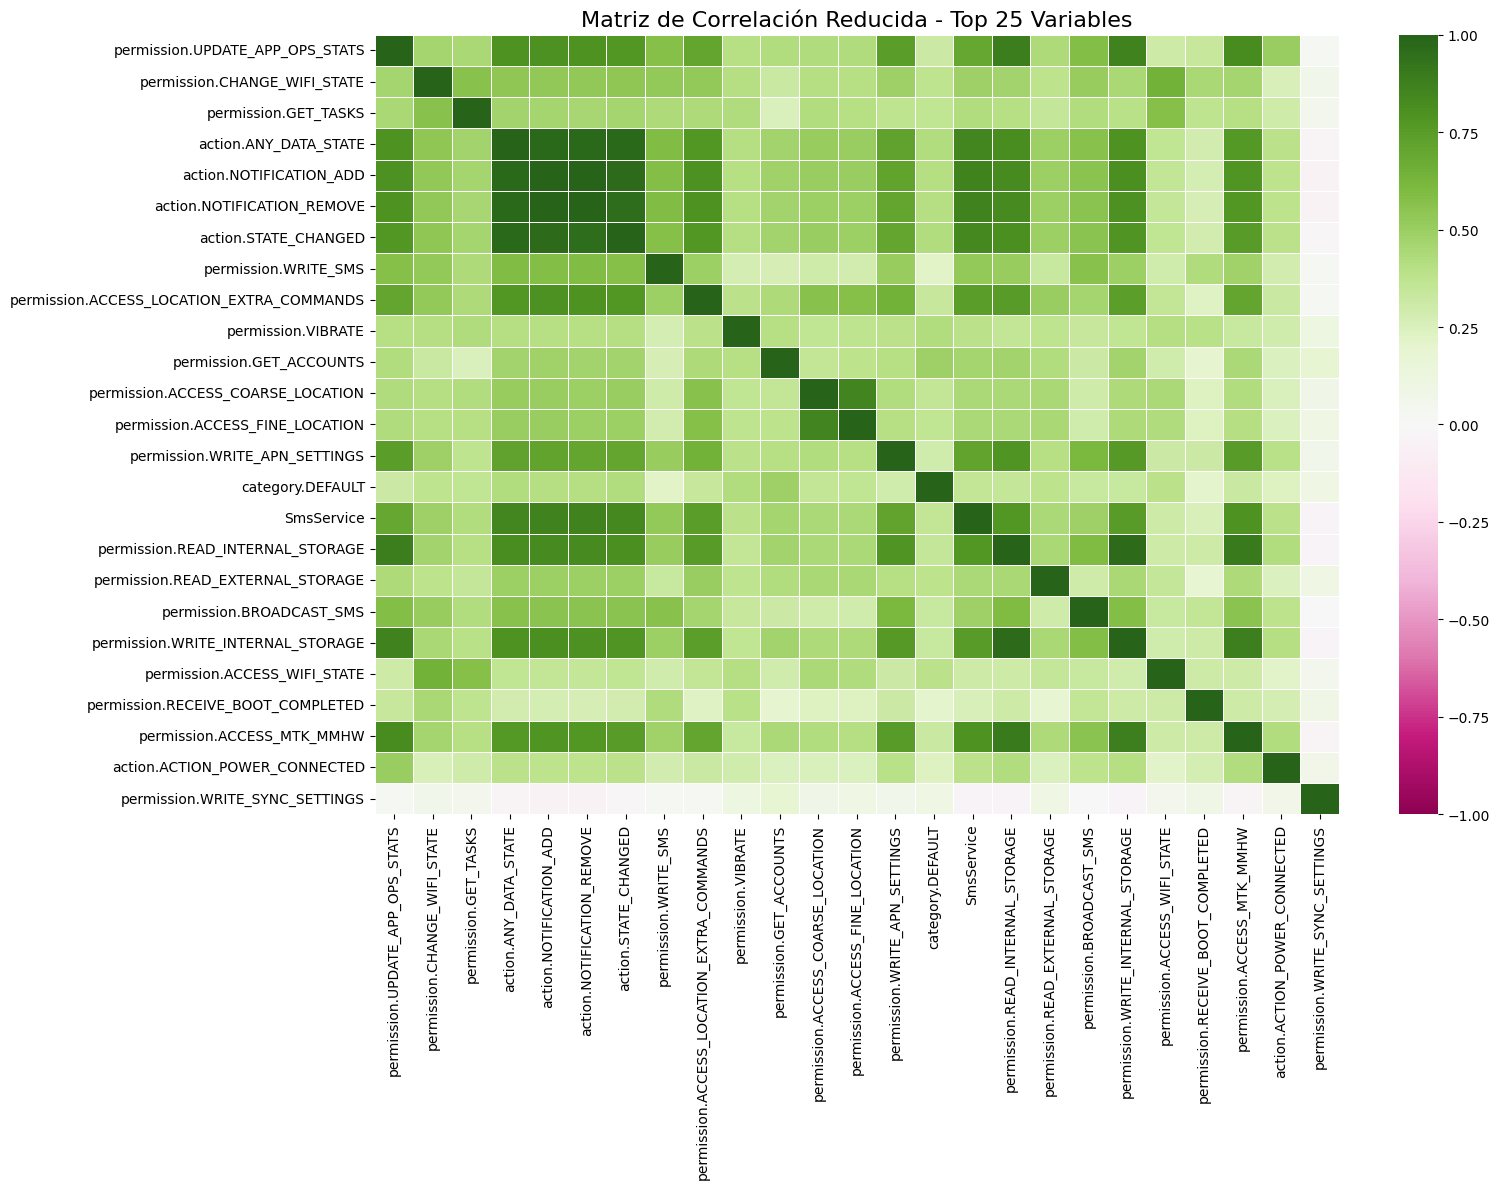

In [50]:
# cantidad de variables a mostrar en la matriz de correlación
k = 25

# usar solo datos numéricos para calcular la correlación
df_numeric = data_df.drop(columns=['Class', 'apk_name'], errors='ignore')

# seleccionar las correlaciones absolutas más altas
full_corr_matrix_abs = df_numeric.corr().abs()
top_k_vars = full_corr_matrix_abs.mean().sort_values(ascending=False).head(k).index

# tomar la submatriz de correlación
real_reduced_corr = df_numeric[top_k_vars].corr()

# visualizar
plt.figure(figsize=(16, 12))
sns.heatmap(real_reduced_corr, 
            annot=False,
            cmap='PiYG',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.title(f'Matriz de Correlación Reducida - Top {k} Variables', fontsize=16)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('images_exploration/matriz_correlacion_reducida.pdf')
plt.show()

### Separabilidad de las clases con t-SNE

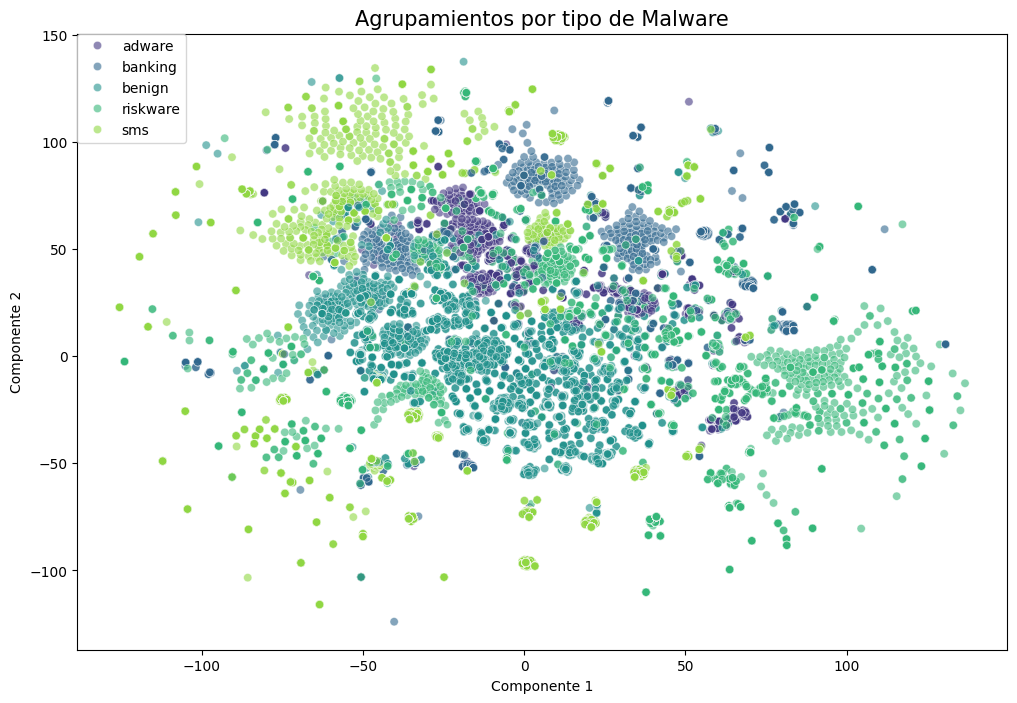

In [51]:
# tomar datos numéricos para t-SNE y categoría
X = data_df.drop(columns=['Class', 'apk_name'], errors='ignore')
y = data_df['Class']

# escalar (t-SNE es sensible a la escala de las características)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ejecutar t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_embedded = tsne.fit_transform(X_scaled)

# visualización de las dos componentes principales
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_embedded[:,0], 
    y=X_embedded[:,1], 
    hue=y, 
    palette='viridis',
    legend='full',
    alpha=0.6
)

plt.title('Agrupamientos por tipo de Malware', fontsize=15)
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend(loc=2, borderaxespad=0.)
plt.savefig('images_exploration/tsne_clases.pdf', bbox_inches='tight')
plt.show()

## Exploración de Imagenes

In [52]:
# lectura de directorios train y test
train_dir = 'datasets/Image/train/'
test_dir = 'datasets/Image/test/'

# contar archivos para obtener distribución de clases - en cada carpeta hay subcarpetas por clase
train_counts = {}
for class_dir in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_dir)
    if os.path.isdir(class_path):
        train_counts[class_dir] = len(os.listdir(class_path))

test_counts = {}
for class_dir in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_dir)
    if os.path.isdir(class_path):
        test_counts[class_dir] = len(os.listdir(class_path))

print("Distribución de clases en Train:", train_counts)
print("Distribución de clases en Test:", test_counts)
print("Total por clase:", {cls: train_counts.get(cls, 0) + test_counts.get(cls, 0) for cls in set(train_counts) | set(test_counts)})
print("Total de imágenes en Train:", sum(train_counts.values()))
print("Total de imágenes en Test:", sum(test_counts.values()))
print("Total de imágenes:", sum(train_counts.values()) + sum(test_counts.values()))

Distribución de clases en Train: {'riskware': 2727, 'sms': 3341, 'benign': 2821, 'banking': 1733, 'adware': 1061}
Distribución de clases en Test: {'riskware': 1165, 'sms': 1464, 'benign': 1209, 'banking': 720, 'adware': 450}
Total por clase: {'banking': 2453, 'benign': 4030, 'riskware': 3892, 'adware': 1511, 'sms': 4805}
Total de imágenes en Train: 11683
Total de imágenes en Test: 5008
Total de imágenes: 16691


Los archivos coinciden con los datos tabulares. Cada imagen lleva como título el nombre del archivo, que en los datos tabulares corresponde a un dato específico con apk_name. Por ejemplo, la imagen "0000c9e7b8a1b2e5c8f1d2e3f4g5h6.png" corresponde al dato con apk_name "0000c9e7b8a1b2e5c8f1d2e3f4g5h6" en los datos tabulares.

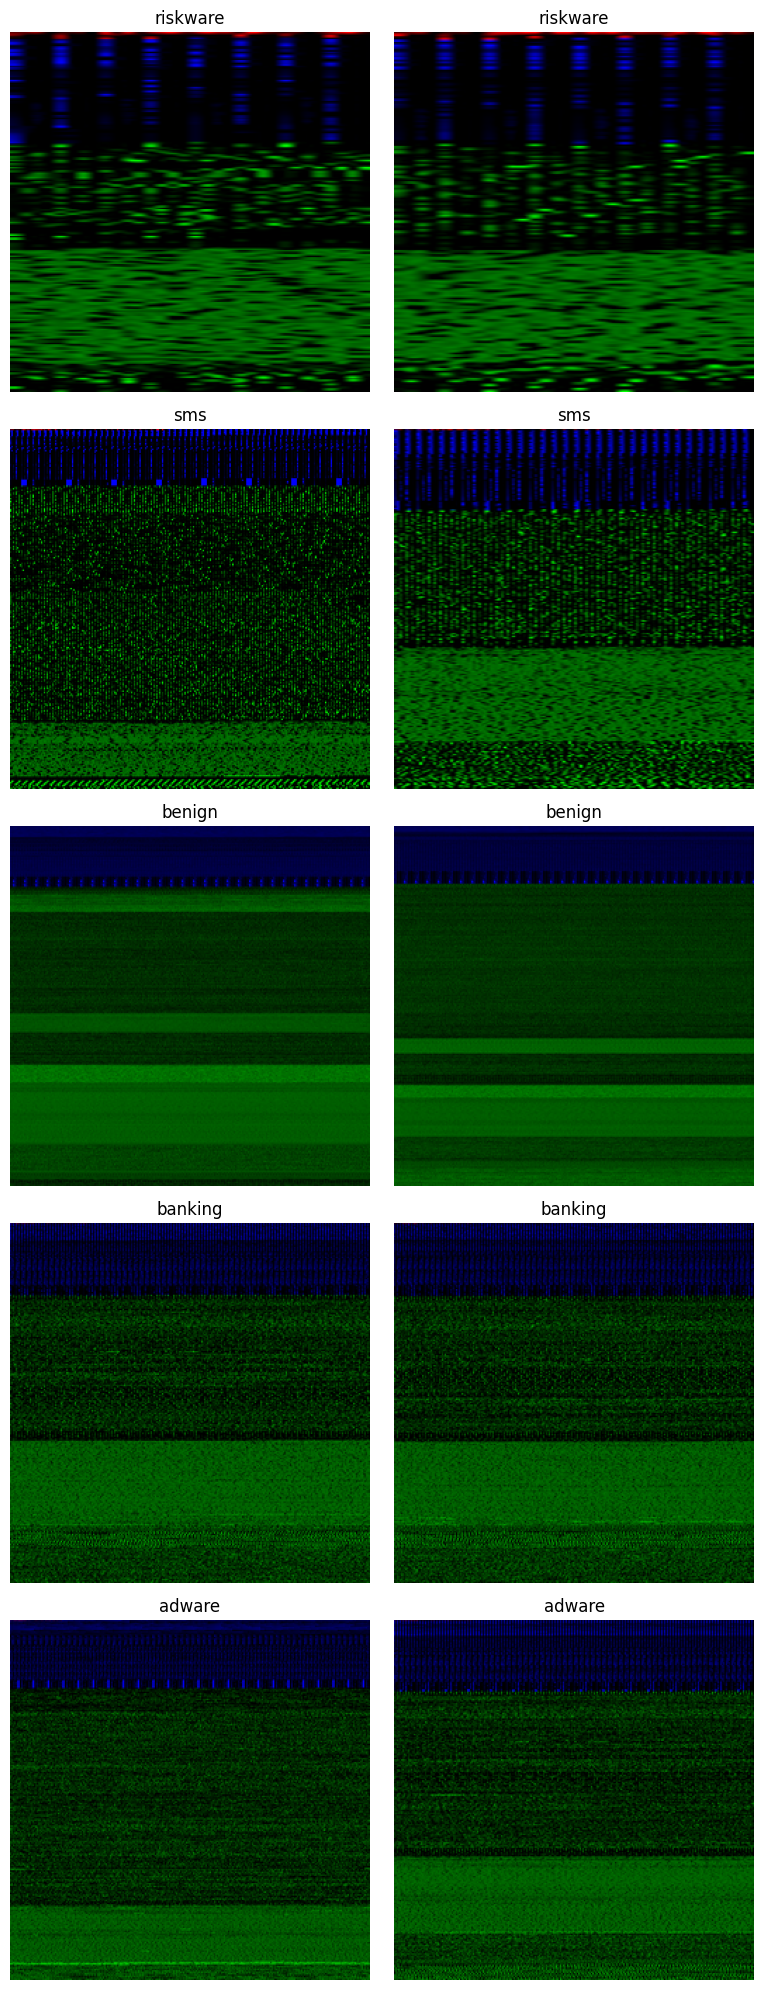

In [53]:
# Visualización de 2 imágenes por clase
classes = list(train_counts.keys())
plt.figure(figsize=(8, 20))
for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)[20:22]  # número de imagenes
    for j, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = plt.imread(img_path)
        plt.subplot(len(classes), 2, i*2 + j + 1)
        plt.imshow(img)
        plt.title(f'{cls}')
        plt.axis('off')
plt.tight_layout()
plt.savefig('images_exploration/ejemplo_imagenes_por_clase.pdf')
plt.show()

In [45]:
# verificar shapes de las imágenes
for cls in classes:
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)[:5]  # revisar las primeras 5 imágenes de cada clase
    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = plt.imread(img_path)
        print(f'Clase: {cls}, Shape: {img.shape}')

Clase: riskware, Shape: (256, 256, 3)
Clase: riskware, Shape: (256, 256, 3)
Clase: riskware, Shape: (256, 256, 3)
Clase: riskware, Shape: (256, 256, 3)
Clase: riskware, Shape: (256, 256, 3)
Clase: sms, Shape: (256, 256, 3)
Clase: sms, Shape: (256, 256, 3)
Clase: sms, Shape: (256, 256, 3)
Clase: sms, Shape: (256, 256, 3)
Clase: sms, Shape: (256, 256, 3)
Clase: benign, Shape: (256, 256, 3)
Clase: benign, Shape: (256, 256, 3)
Clase: benign, Shape: (256, 256, 3)
Clase: benign, Shape: (256, 256, 3)
Clase: benign, Shape: (256, 256, 3)
Clase: banking, Shape: (256, 256, 3)
Clase: banking, Shape: (256, 256, 3)
Clase: banking, Shape: (256, 256, 3)
Clase: banking, Shape: (256, 256, 3)
Clase: banking, Shape: (256, 256, 3)
Clase: adware, Shape: (256, 256, 3)
Clase: adware, Shape: (256, 256, 3)
Clase: adware, Shape: (256, 256, 3)
Clase: adware, Shape: (256, 256, 3)
Clase: adware, Shape: (256, 256, 3)


Cada imagen es de tamaño 256x256 con 3 canales (RGB).